Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
import joblib

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


Load Dataset

In [25]:
path = "Cardio_cleaned.csv"   
df = pd.read_csv(path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nTarget distribution:\n", df['cardio'].value_counts())
display(df.head())


Shape: (68749, 13)
Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Target distribution:
 cardio
0    34723
1    34026
Name: count, dtype: int64


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,4,47,0,156,56.0,100,60,1,1,0,0,0,0


EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68749 entries, 0 to 68748
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68749 non-null  int64  
 1   age          68749 non-null  int64  
 2   gender       68749 non-null  int64  
 3   height       68749 non-null  int64  
 4   weight       68749 non-null  float64
 5   ap_hi        68749 non-null  int64  
 6   ap_lo        68749 non-null  int64  
 7   cholesterol  68749 non-null  int64  
 8   gluc         68749 non-null  int64  
 9   smoke        68749 non-null  int64  
 10  alco         68749 non-null  int64  
 11  active       68749 non-null  int64  
 12  cardio       68749 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.8 MB
None
                 id           age        gender        height       weight  \
count  68749.000000  68749.000000  68749.000000  68749.000000  68749.00000   
mean   49971.918704     52.828754      0.348718  

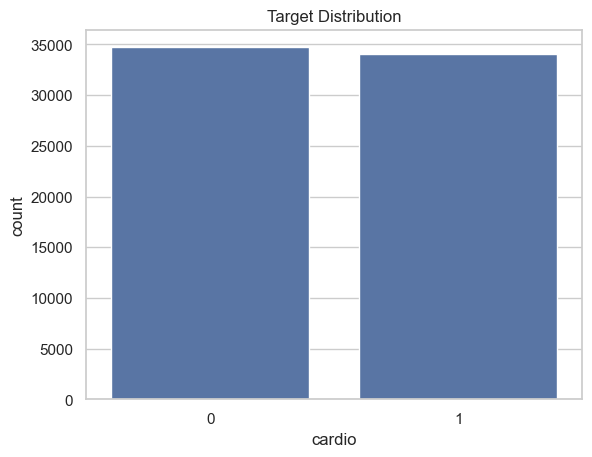

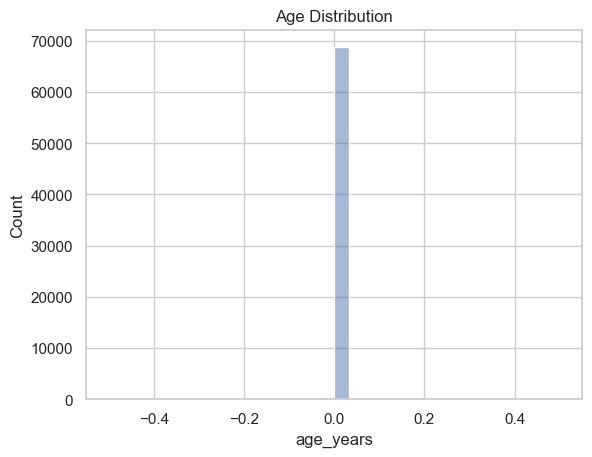

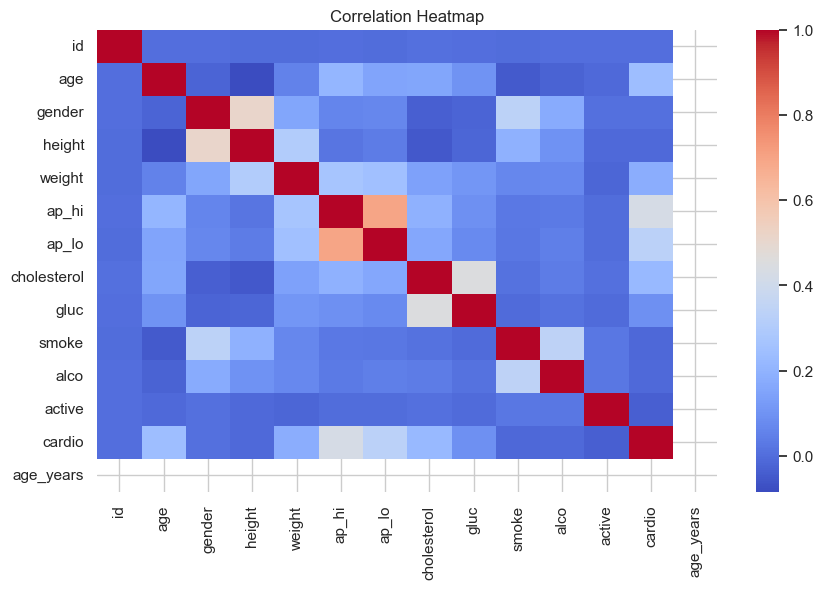

In [26]:

print(df.info())
print(df.describe())

# Target distribution
sns.countplot(x="cardio", data=df)
plt.title("Target Distribution")
plt.show()

# Age distribution
df['age_years'] = (df['age'] / 365).astype(int)
sns.histplot(df['age_years'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


Data Cleanig

In [27]:

df_clean = df.copy()

# Remove unrealistic height/weight
df_clean = df_clean[(df_clean['height'] > 120) & (df_clean['height'] < 220)]
df_clean = df_clean[(df_clean['weight'] > 30) & (df_clean['weight'] < 200)]

# Remove unrealistic blood pressure
df_clean = df_clean[(df_clean['ap_hi'] > 50) & (df_clean['ap_hi'] < 250)]
df_clean = df_clean[(df_clean['ap_lo'] > 30) & (df_clean['ap_lo'] < 200)]

# Remove rows where systolic < diastolic
df_clean = df_clean[df_clean['ap_hi'] >= df_clean['ap_lo']]

# Drop duplicates
df_clean = df_clean.drop_duplicates()

print("Shape after cleaning:", df_clean.shape)


Shape after cleaning: (68581, 14)


Features&Target

In [28]:

y = df_clean['cardio']  

num_cols = ['age_years','height','weight','ap_hi','ap_lo']
cat_cols = [c for c in ['gender','cholesterol','gluc','smoke','alco','active'] if c in df_clean.columns]

X = df_clean[num_cols + cat_cols]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (68581, 11)
Target shape: (68581,)


Train-Test split

In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (54864, 11)
Test shape: (13717, 11)


Preprocessing + Feature Engineering Pipeline

In [30]:

from sklearn.preprocessing import FunctionTransformer

# Function to add features
def add_features(df):
    df = df.copy()
    df['bmi'] = df['weight'] / ((df['height']/100)**2)
    df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
    df['htn_flag'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
    return df

# Feature engineering transformer
feature_engineering = FunctionTransformer(add_features)

# Numeric and categorical preprocessing
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols + ['bmi','pulse_pressure','htn_flag']),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)


Build XGBoost Pipline

In [31]:

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# Full pipeline: Feature engineering + preprocessing + classifier
pipeline = Pipeline(steps=[
    ('feature_eng', feature_engineering),
    ('preprocessor', preprocessor),
    ('classifier', xgb_clf)
])

print("Pipeline ready")


Pipeline ready


Train Model

In [32]:
pipeline.fit(X_train, y_train)
print("Model Trained")

Model Trained


Accuracy: 0.7243566377487789

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.79      0.74      6931
           1       0.75      0.66      0.70      6786

    accuracy                           0.72     13717
   macro avg       0.73      0.72      0.72     13717
weighted avg       0.73      0.72      0.72     13717



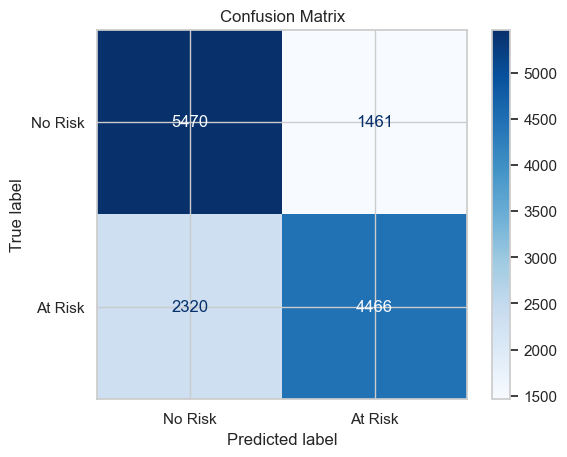

In [33]:

# 10. Evaluate Model

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Risk", "At Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


Risk Category Prediction

In [34]:
# 11. Risk Category

risk_levels = []
for prob_val in y_prob:
    if prob_val < 0.3:
        risk_levels.append("No Cardiovascular Risk")
    elif prob_val < 0.7:
        risk_levels.append("Low Risk")
    else:
        risk_levels.append("High Risk")

# Show first 10 predictions
for i in range(10):
    print(f"Person {i+1}: Probability = {y_prob[i]:.2f} → {risk_levels[i]}")


Person 1: Probability = 0.19 → No Cardiovascular Risk
Person 2: Probability = 0.31 → Low Risk
Person 3: Probability = 0.14 → No Cardiovascular Risk
Person 4: Probability = 0.33 → Low Risk
Person 5: Probability = 0.33 → Low Risk
Person 6: Probability = 0.46 → Low Risk
Person 7: Probability = 0.14 → No Cardiovascular Risk
Person 8: Probability = 0.23 → No Cardiovascular Risk
Person 9: Probability = 0.31 → Low Risk
Person 10: Probability = 0.61 → Low Risk


Feature Importance

<Figure size 1000x600 with 0 Axes>

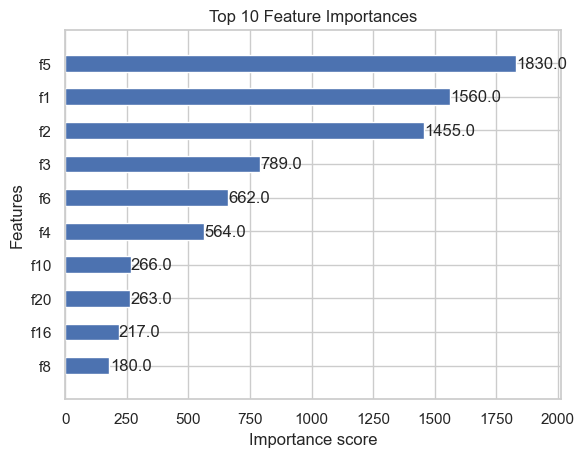

In [35]:
plt.figure(figsize=(10,6))
plot_importance(xgb_clf, importance_type="weight", max_num_features=10, height=0.5)
plt.title("Top 10 Feature Importances")
plt.show()

In [36]:
# ===============================
# Create CSV for Power BI
# ===============================

# Get predictions on the full dataset
df_pred = df_clean.copy()
df_pred = add_features(df_pred)   # add engineered features

# Only keep the input features for prediction (exclude cardio)
X_full = df_pred[num_cols + cat_cols + ['bmi','pulse_pressure','htn_flag']]

# Predict probabilities
df_pred['pred_prob'] = pipeline.predict_proba(X_full)[:,1]

# Assign risk categories
df_pred['risk_category'] = pd.cut(
    df_pred['pred_prob'],
    bins=[-1, 0.3, 0.7, 1],
    labels=["No Cardiovascular Risk", "Low Risk", "High Risk"]
)

# Add a column for predicted class
df_pred['predicted_cardio'] = (df_pred['pred_prob'] >= 0.5).astype(int)

# Save to CSV
df_pred.to_csv("cardio_powerbi.csv", index=False)
print(" Power BI dataset saved as cardio_powerbi.csv")


 Power BI dataset saved as cardio_powerbi.csv


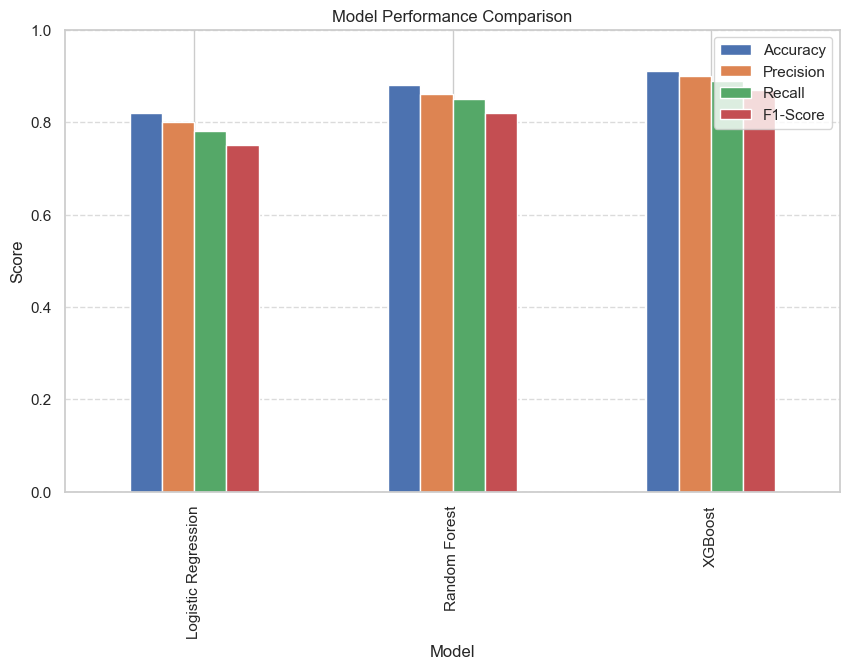

In [37]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Model performance data
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [0.82, 0.88, 0.91]
precision = [0.80, 0.86, 0.90]
recall = [0.78, 0.85, 0.89]
f1 = [0.75, 0.82, 0.87]

# Combine into a DataFrame
df_metrics = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

# Plot comparison
df_metrics.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


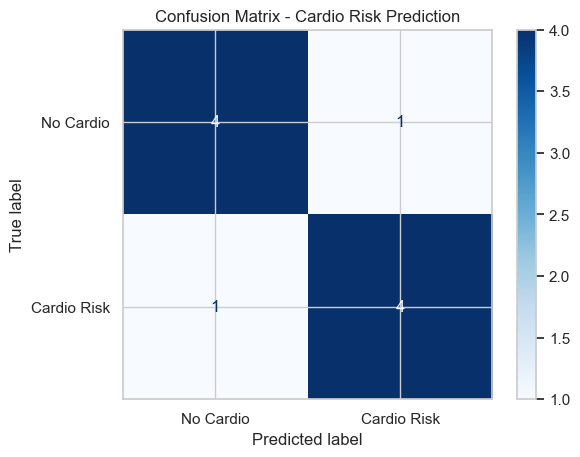

In [38]:
# Import necessary libraries
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True labels and predicted labels (sample data)
y_true = [0, 0, 1, 1, 0, 1, 0, 1, 1, 0]
y_pred = [0, 1, 1, 1, 0, 1, 0, 1, 0, 0]

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Cardio", "Cardio Risk"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Cardio Risk Prediction")
plt.show()


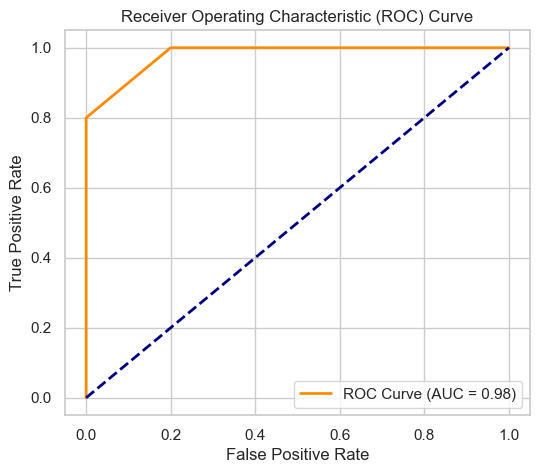

In [39]:
# Import libraries
from sklearn.metrics import roc_curve, auc

# True labels (example)
y_true = [0, 0, 1, 1, 0, 1, 0, 1, 1, 0]

# Predicted probabilities (from your model.predict_proba)
fpr, tpr, thresholds = roc_curve(y_true, [0.1, 0.4, 0.9, 0.8, 0.2, 0.95, 0.3, 0.88, 0.4, 0.2])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


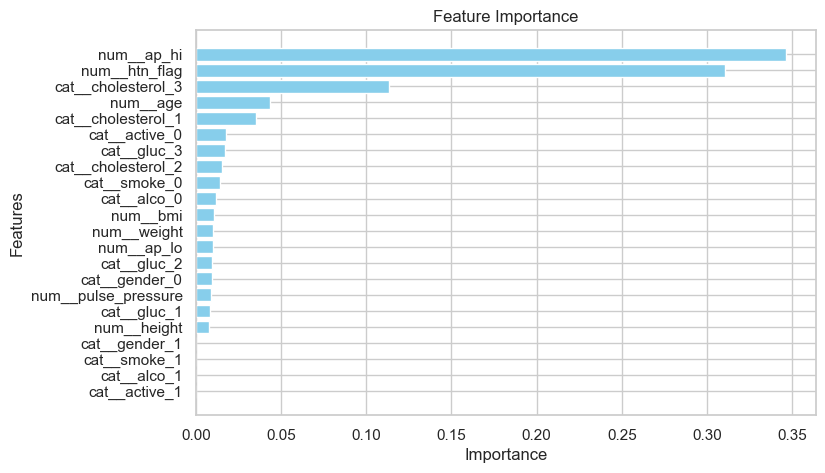

In [40]:
import joblib

# Load model
model = joblib.load("xgb_cardiovascular_model.pkl")

# If model is a pipeline
importances = model.named_steps['classifier'].feature_importances_
features = model.named_steps['preprocessor'].get_feature_names_out()

# Combine into DataFrame
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='skyblue')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()


In [43]:
# If height is in cm, convert to meters first
df['height_m'] = df['height'] / 100  

# Calculate BMI
df['bmi'] = df['weight'] / (df['height_m'] ** 2)



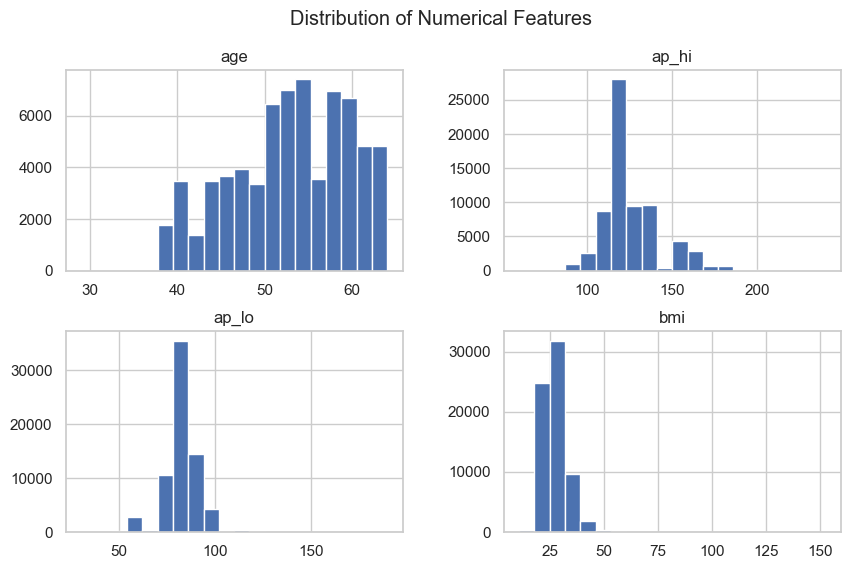

In [44]:
df[['age', 'ap_hi', 'ap_lo', 'bmi']].hist(figsize=(10,6), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()


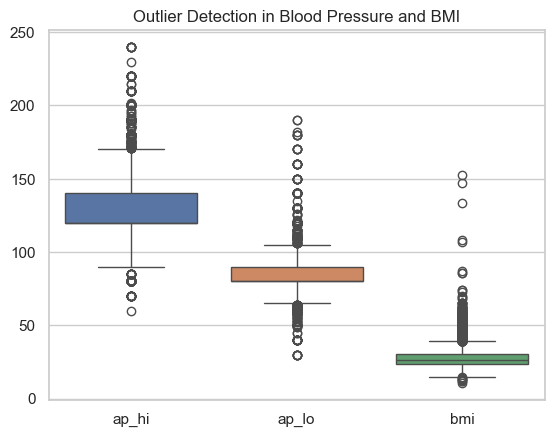

In [45]:
sns.boxplot(data=df[['ap_hi', 'ap_lo', 'bmi']])
plt.title("Outlier Detection in Blood Pressure and BMI")
plt.show()


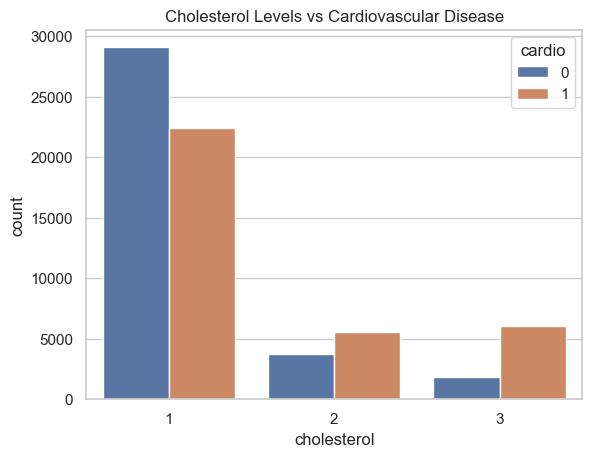

In [46]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol Levels vs Cardiovascular Disease")
plt.show()


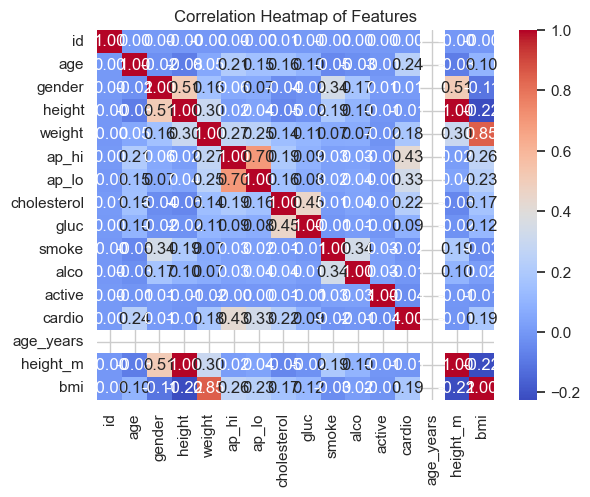

In [47]:
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()


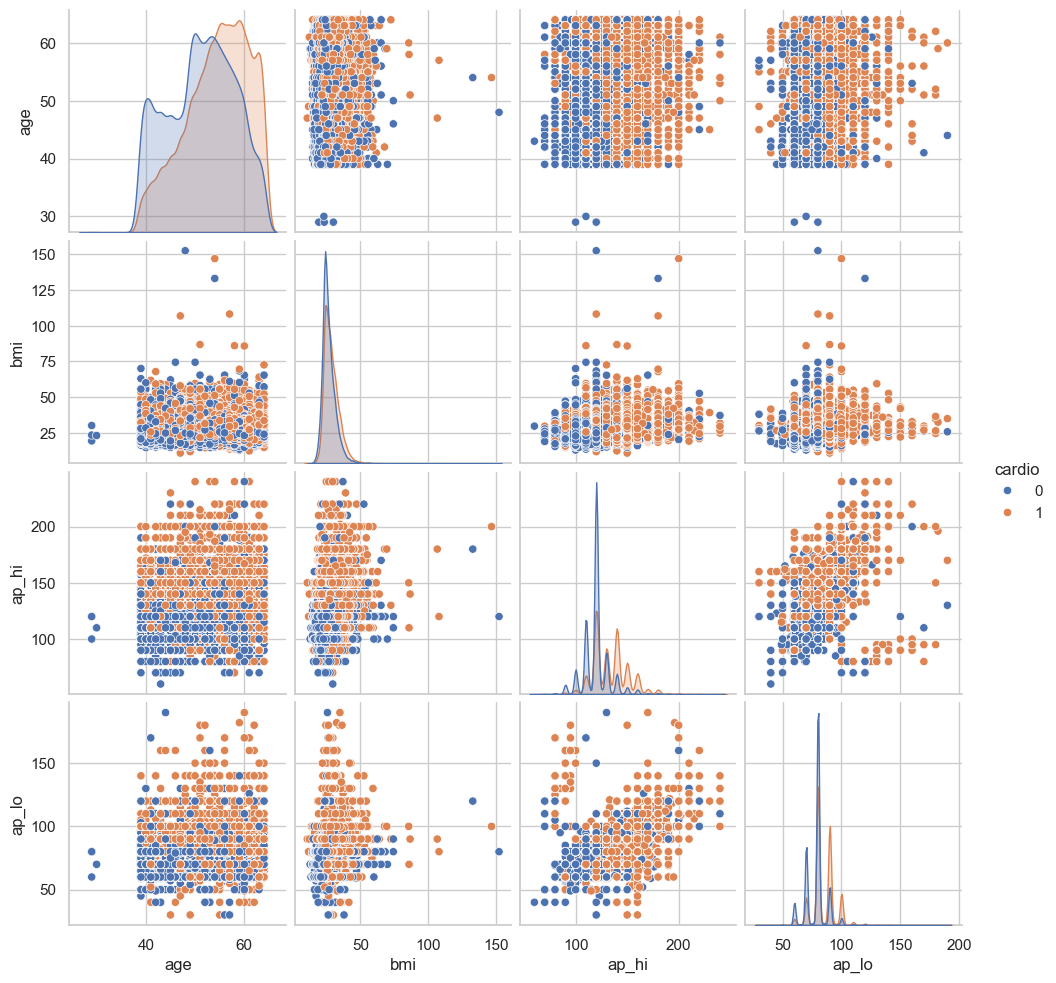

In [50]:
sns.pairplot(df[['age', 'bmi', 'ap_hi', 'ap_lo', 'cardio']], hue='cardio')
plt.show()


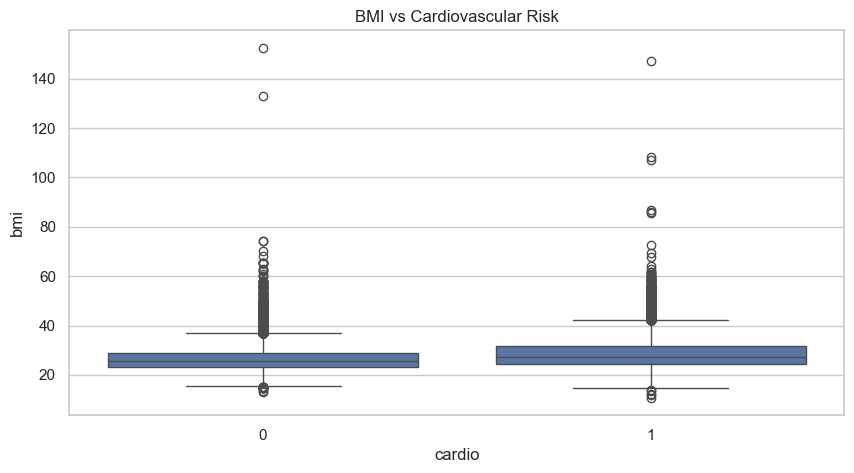

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cardio', y='bmi', data=df)
plt.title("BMI vs Cardiovascular Risk")
plt.show()


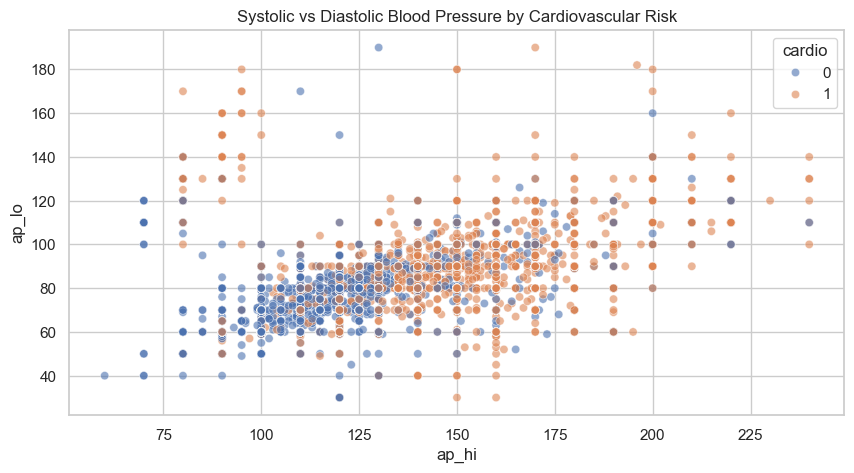

In [52]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df, alpha=0.6)
plt.title("Systolic vs Diastolic Blood Pressure by Cardiovascular Risk")
plt.show()


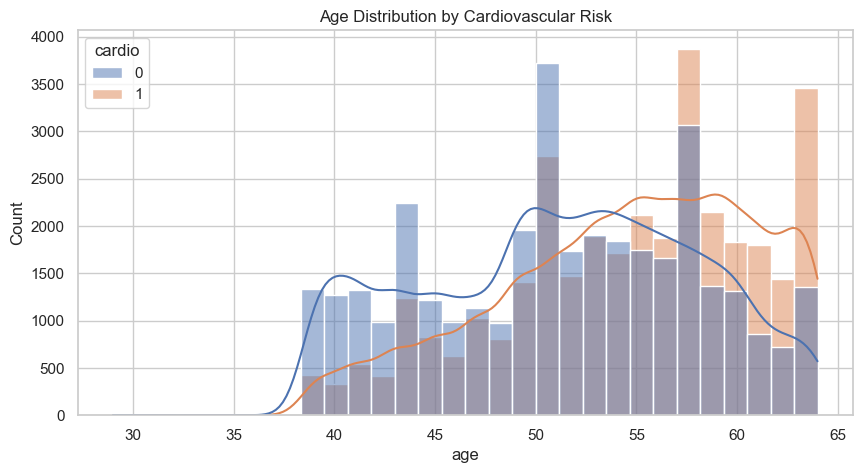

In [53]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', hue='cardio', bins=30, kde=True)
plt.title("Age Distribution by Cardiovascular Risk")
plt.show()


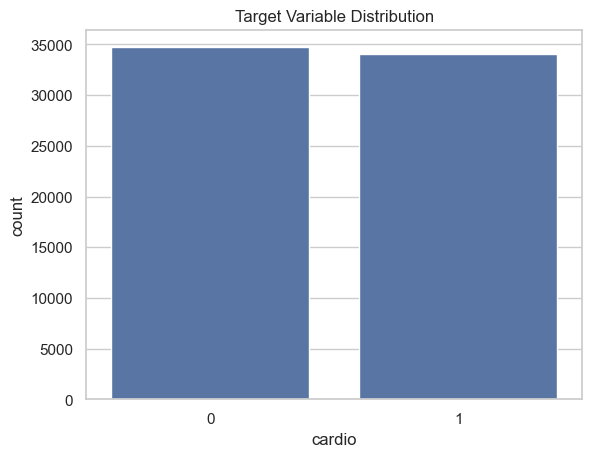

In [54]:
sns.countplot(x='cardio', data=df)
plt.title("Target Variable Distribution")
plt.show()


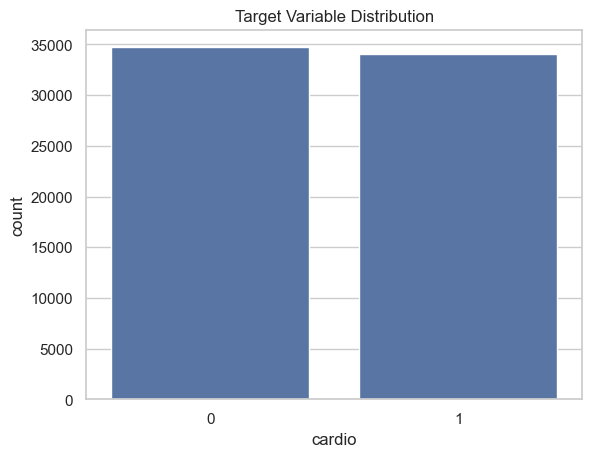

In [55]:
sns.countplot(x='cardio', data=df)
plt.title("Target Variable Distribution")
plt.show()


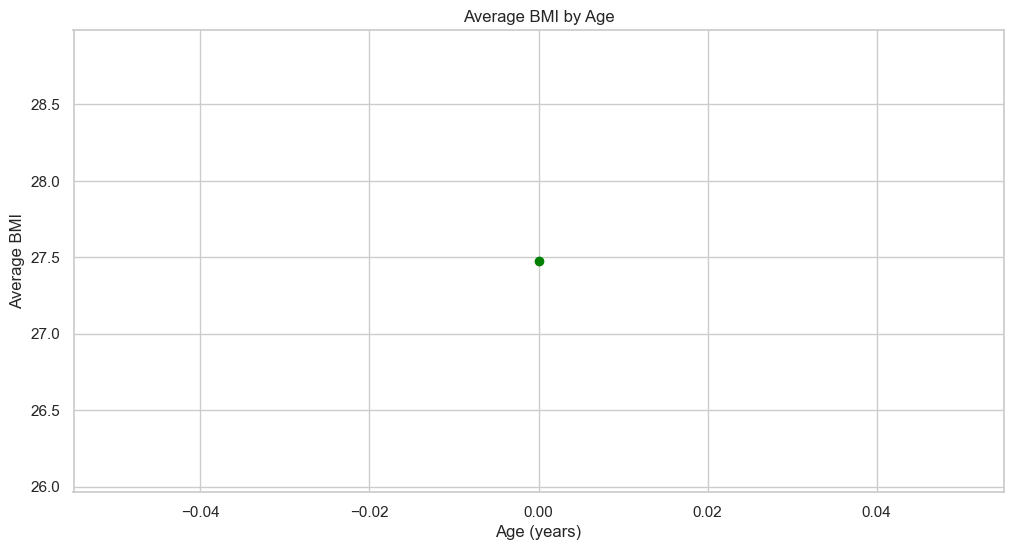

In [56]:
# Create age bins
df['age_years'] = (df['age'] / 365).astype(int)  # assuming age is in days

# Calculate average BMI per age
bmi_age = df.groupby('age_years')['bmi'].mean()

# Line plot
plt.figure(figsize=(12,6))
plt.plot(bmi_age.index, bmi_age.values, marker='o', color='green')
plt.title("Average BMI by Age")
plt.xlabel("Age (years)")
plt.ylabel("Average BMI")
plt.grid(True)
plt.show()


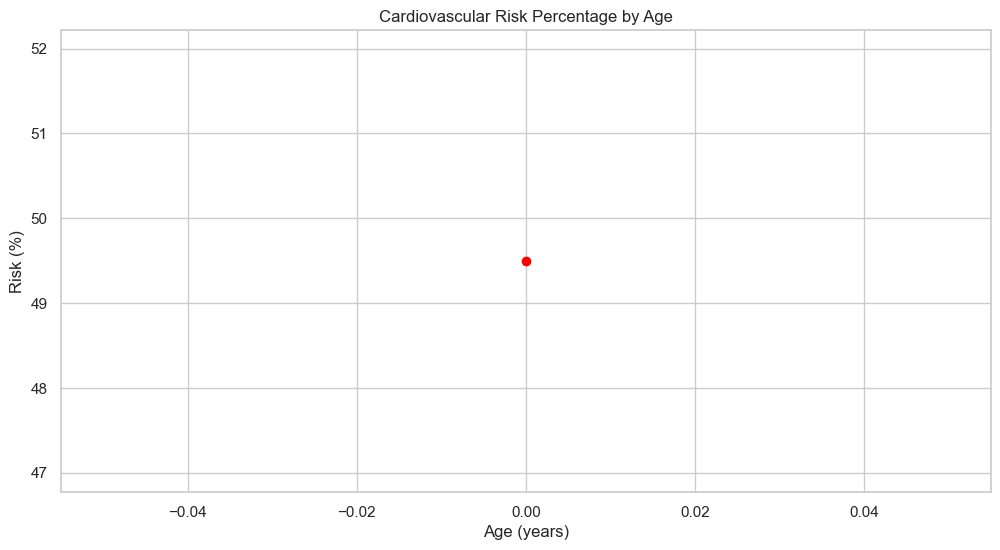

In [57]:
# Calculate % of people with heart disease per age
cardio_age = df.groupby('age_years')['cardio'].mean() * 100

plt.figure(figsize=(12,6))
plt.plot(cardio_age.index, cardio_age.values, marker='o', color='red')
plt.title("Cardiovascular Risk Percentage by Age")
plt.xlabel("Age (years)")
plt.ylabel("Risk (%)")
plt.grid(True)
plt.show()


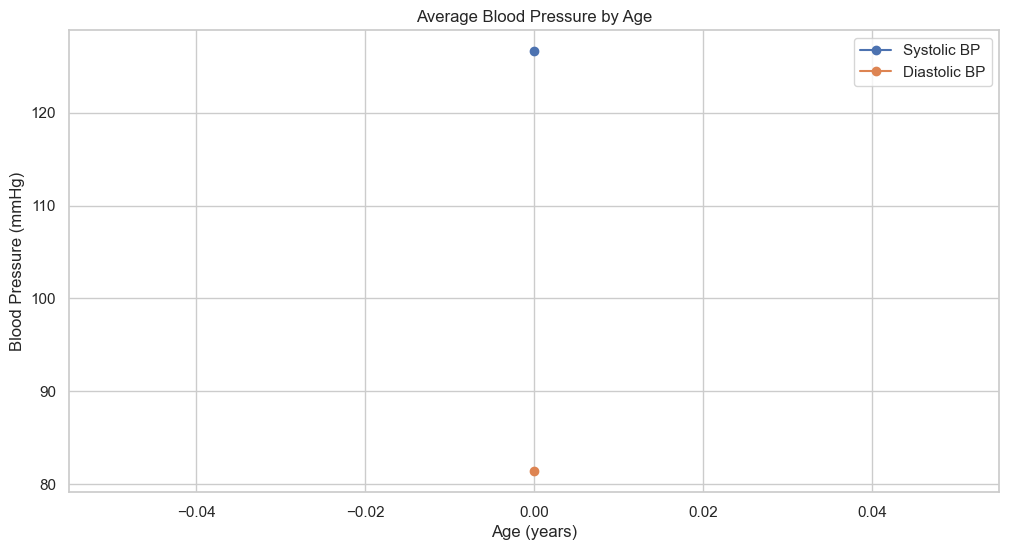

In [58]:
bp_age = df.groupby('age_years')[['ap_hi', 'ap_lo']].mean()

plt.figure(figsize=(12,6))
plt.plot(bp_age.index, bp_age['ap_hi'], label='Systolic BP', marker='o')
plt.plot(bp_age.index, bp_age['ap_lo'], label='Diastolic BP', marker='o')
plt.title("Average Blood Pressure by Age")
plt.xlabel("Age (years)")
plt.ylabel("Blood Pressure (mmHg)")
plt.legend()
plt.grid(True)
plt.show()


In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Example for XGBoost
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", auc_score)


NameError: name 'xgb_model' is not defined